# CIFAR-10 Image Classification using CNN

## AI/ML Internship Project

### Objective

Build a Convolutional Neural Network (CNN) to classify images into 10 object categories using the CIFAR-10 dataset.

### Deep Learning Framework

TensorFlow & Keras

### Dataset

CIFAR-10 Dataset (Built-in TensorFlow Dataset)

### Classes

- Airplane
- Automobile
- Bird
- Cat
- Deer
- Dog
- Frog
- Horse
- Ship
- Truck

# Import Required Libraries

In [23]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.utils import to_categorical

In [24]:
print(cifar10)

<module 'keras.datasets.cifar10' from '/Users/khushi/AI-ML-Projects/dl_env/lib/python3.12/site-packages/keras/datasets/cifar10/__init__.py'>


# Verify TensorFlow Installation

In [25]:
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.16.2


# Load the CIFAR-10 Dataset

The CIFAR-10 dataset contains **60,000 colour images** belonging to **10 different classes**.

- Training Images : 50,000
- Testing Images : 10,000

Each image has a size of **32 × 32 pixels**.

In [26]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Dataset Information

The CIFAR-10 dataset contains **60,000 RGB images** divided into **10 different object categories**.

- Training Images : 50,000
- Testing Images : 10,000
- Image Size : 32 × 32 pixels
- Color Channels : 3 (RGB)

In [27]:
print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)

print("Testing Images :", X_test.shape)
print("Testing Labels :", y_test.shape)

Training Images : (50000, 32, 32, 3)
Training Labels : (50000, 1)
Testing Images : (10000, 32, 32, 3)
Testing Labels : (10000, 1)


# Define Class Labels

Each numerical label in the dataset corresponds to one of the following object classes.

In [28]:
class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

print(class_names)

['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']


# Visualize Sample Images

Display a few sample images from the training dataset along with their corresponding class labels.

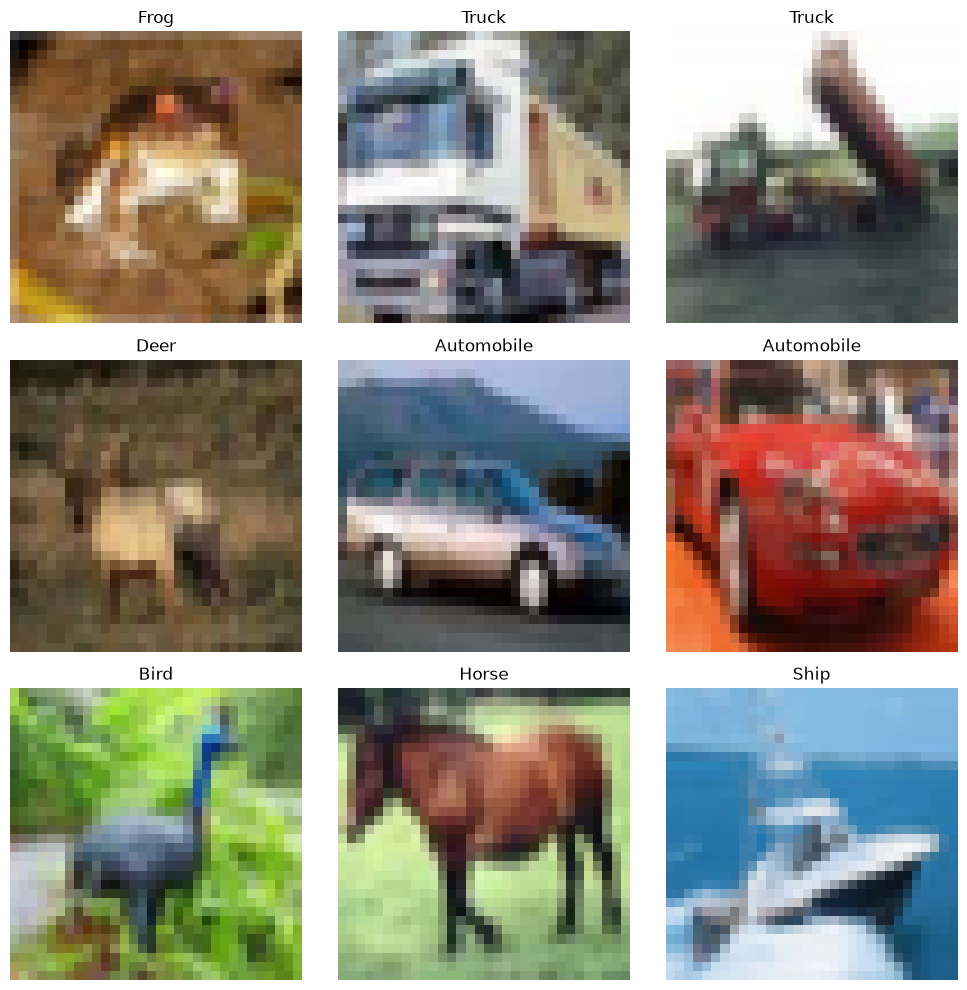

In [29]:
plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

# Data Preprocessing

Normalize pixel values from **0–255** to **0–1**.

Normalization helps the neural network train faster and improves model performance.

In [30]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# One-Hot Encoding

Convert categorical labels into one-hot encoded vectors for multi-class classification.

In [31]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Verify Dataset After Preprocessing

Check the shapes of the processed training data and labels.

In [32]:
print("Training Images Shape :", X_train.shape)
print("Training Labels Shape :", y_train.shape)

print("Testing Images Shape :", X_test.shape)
print("Testing Labels Shape :", y_test.shape)

Training Images Shape : (50000, 32, 32, 3)
Training Labels Shape : (50000, 10)
Testing Images Shape : (10000, 32, 32, 3)
Testing Labels Shape : (10000, 10)


# Display a Normalized Image

Visualize one normalized image to verify that preprocessing has been applied successfully.

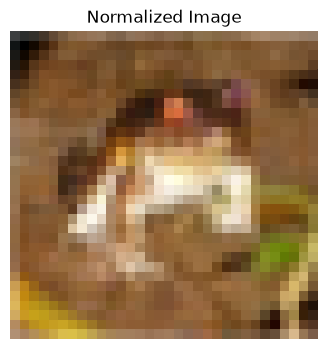

In [33]:
plt.figure(figsize=(4,4))
plt.imshow(X_train[0])
plt.title("Normalized Image")
plt.axis("off")
plt.show()

# Build the Convolutional Neural Network (CNN)

A Convolutional Neural Network (CNN) is designed specifically for image classification tasks.

The architecture used in this project consists of:

- Convolution Layer
- Max Pooling Layer
- Convolution Layer
- Max Pooling Layer
- Flatten Layer
- Fully Connected (Dense) Layer
- Dropout Layer
- Output Layer

In [34]:
model = Sequential()

# First Convolution Block
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Block
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))

# Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))

# Model Summary

Display the architecture of the CNN model including all layers and trainable parameters.

In [35]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

# Compile the Model

Configure the model for training by specifying:

- Optimizer : Adam
- Loss Function : Categorical Crossentropy
- Evaluation Metric : Accuracy

In [36]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the CNN Model

Train the model using the training dataset.

Parameters used:

- Epochs : 10
- Batch Size : 64
- Validation Split : 20%

In [37]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 73s 112ms/step - accuracy: 0.3707 - loss: 1.7121 - val_accuracy: 0.5097 - val_loss: 1.4165
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 97s 154ms/step - accuracy: 0.4931 - loss: 1.4065 - val_accuracy: 0.5751 - val_loss: 1.2285
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 97s 155ms/step - accuracy: 0.5428 - loss: 1.2816 - val_accuracy: 0.6026 - val_loss: 1.1252
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 93s 149ms/step - accuracy: 0.5786 - loss: 1.1906 - val_accuracy: 0.6391 - val_loss: 1.0372
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 136ms/step - accuracy: 0.6007 - loss: 1.1275 - val_accuracy: 0.6448 - val_loss: 1.0147
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 141s 135ms/step - accuracy: 0.6202 - loss: 1.0774 - val_accuracy: 0.6575 - val_loss: 0.9915
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 137ms/step - accuracy: 0.6369 - loss: 1.0326 - val_accuracy: 0.6631 - val_loss: 0.9527
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 93s 149ms/step - accuracy: 0.6519 - loss: 

# Evaluate Model Performance

Evaluate the trained CNN using the testing dataset.

In [38]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6880 - loss: 0.8975
Test Loss : 0.8974617123603821
Test Accuracy : 0.6880000233650208


# Training and Validation Accuracy

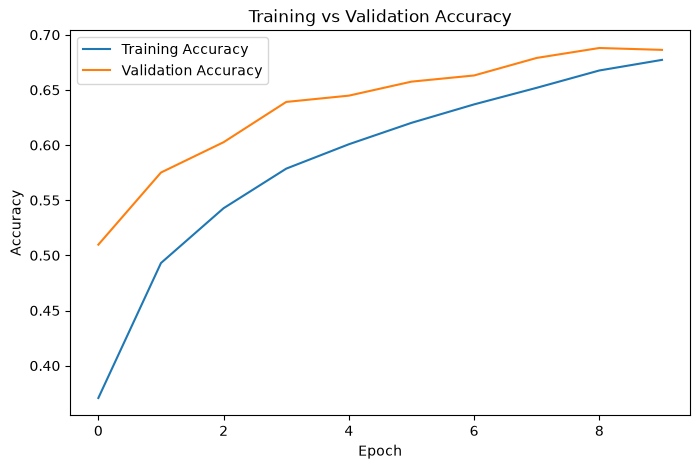

In [39]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

# Training and Validation Loss

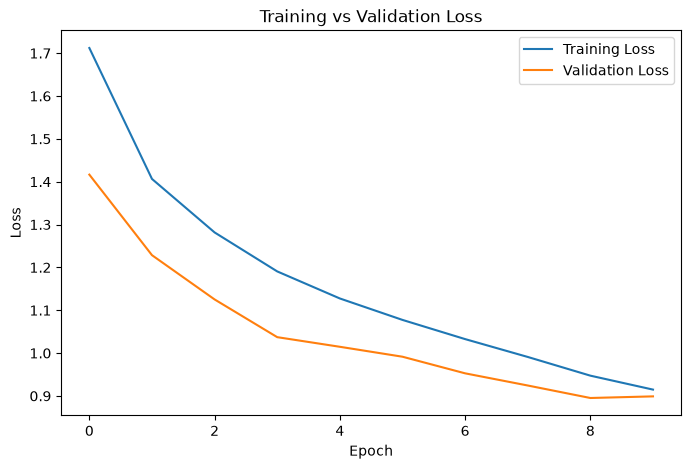

In [40]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

# Save the Trained CNN Model

Save the trained model for future predictions.

In [41]:
model.save("../models/cifar10_cnn_model.keras")

print("Model saved successfully.")

Model saved successfully.


# Predict Sample Images

Use the trained model to predict image classes from the test dataset.

In [42]:
predictions = model.predict(X_test)

predicted_class = np.argmax(predictions[0])
actual_class = np.argmax(y_test[0])

print("Predicted Class :", class_names[predicted_class])
print("Actual Class :", class_names[actual_class])

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step
Predicted Class : Cat
Actual Class : Cat


# Visualize Prediction

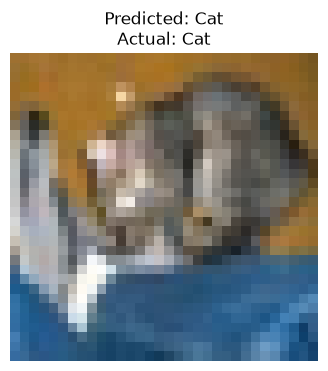

In [43]:
plt.figure(figsize=(4,4))

plt.imshow(X_test[0])

plt.title(
    f"Predicted: {class_names[predicted_class]}\nActual: {class_names[actual_class]}"
)

plt.axis("off")
plt.show()

# Conclusion

In this project, a Convolutional Neural Network (CNN) was developed using TensorFlow and Keras to classify images from the CIFAR-10 dataset into ten object categories.

The model was trained, evaluated, and achieved satisfactory classification accuracy on the testing dataset. The trained model was successfully saved and used to predict unseen images.

This project demonstrates the complete deep learning workflow, including data preprocessing, model building, training, evaluation, visualization, and prediction.